In [143]:
%load_ext autoreload
%autoreload 2

from SRC.pairs_trading import PairsBacktest
from SRC.data_loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [144]:
tickers = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'LTC-USD', 'BCH-USD']
years = 1

In [145]:
# testing yield curve data
loader = DataLoader(years)
loader.market_data(years, tickers)
curve = loader.usyields()


[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


In [146]:
market_data = loader.ticker_a

In [147]:
market_data

'LTC-USD'

In [148]:
curve

,Repo,One_Month_US,Three_Month_US,Six_Month_US,One_Year_US,Two_Year_US,Three_year_US,Five_Year_US,Ten_Year_US,Twenty_Year_US,Thirty_Year_US
2025-06-30,4.33,4.28,4.41,4.29,3.96,3.72,3.68,3.79,4.24,4.79,4.78
2025-07-01,4.33,4.32,4.40,4.29,3.98,3.78,3.75,3.84,4.26,4.79,4.78
2025-07-02,4.33,4.33,4.41,4.28,3.99,3.78,3.77,3.87,4.30,4.84,4.82
2025-07-03,4.33,4.35,4.42,4.34,4.07,3.88,3.84,3.94,4.35,4.87,4.86
2025-07-04,4.33,4.35,4.42,4.34,4.07,3.88,3.84,3.94,4.35,4.87,4.86
...,...,...,...,...,...,...,...,...,...,...,...
2026-06-21,3.63,3.69,3.83,3.92,4.00,4.19,4.19,4.23,4.46,4.91,4.90
2026-06-22,3.63,3.66,3.85,3.98,4.04,4.24,4.25,4.29,4.51,4.97,4.95
2026-06-23,3.63,3.65,3.85,3.96,4.01,4.16,4.22,4.27,4.50,4.96,4.94
2026-06-24,3.63,3.66,3.85,3.95,3.99,4.11,4.15,4.17,4.41,4.87,4.86


In [151]:
%%capture
# Initialize the backtester
backtester = PairsBacktest(years, tickers, lookback_window=20, entry_z=2)

ticker_a = loader.ticker_a
ticker_b = loader.ticker_b
results = backtester.compute_metrics()


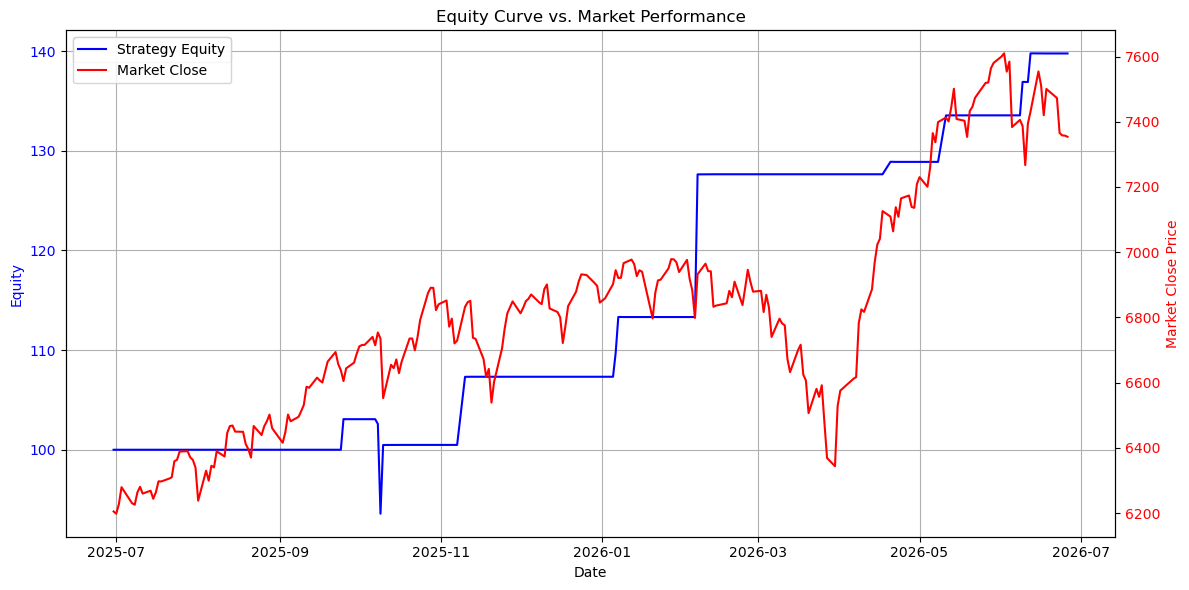

The tickers with the highest correlation, and the ones used in the pairs-trading strategy were LTC-USD and XRP-USD. This strategy used a z-score level of 2.
{'Error': 'Insufficient aligned data for metric calculation after dropping NaNs.'}


In [152]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Equity Curve on primary y-axis
sns.lineplot(x=backtester.data.index, y=backtester.data['Equity'], ax=ax1, color='blue', label='Strategy Equity')
ax1.set_xlabel('Date')
ax1.set_ylabel('Equity', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Create a second y-axis for Market Data
ax2 = ax1.twinx()
sns.lineplot(x=backtester.market_data.index, y=backtester.market_data['Close'].squeeze(), ax=ax2, color='red', label='Market Close')
ax2.set_ylabel('Market Close Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Equity Curve vs. Market Performance')

# Add legends for both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"The tickers with the highest correlation, and the ones used in the pairs-trading strategy were {ticker_a} and {ticker_b}. This strategy used a z-score level of {backtester.entry_z}.")
print(results)

In [ ]:
data = backtester.data.dropna()

In [ ]:
data

,Price_A,Price_B,Log_A,Log_B,Spread,Mean,Std,Z_Score,Pos_A,Pos_B,Active_Pos_A,Active_Pos_B,Ret_A,Ret_B,Strat_Ret_A,Strat_Ret_B,Total_Strat_Return,Equity
Date,,,,,,,,,,,,,,,,,,
2025-07-28,108.594376,3.115842,4.687620,1.136499,3.606819,3.609024,0.082300,-0.026788,0.0,0.0,0.0,0.0,-0.045875,-0.008237,-0.0,-0.0,-0.0,100.000000
2025-07-29,108.532341,3.128431,4.687048,1.140532,3.602413,3.604758,0.080190,-0.029237,0.0,0.0,0.0,0.0,-0.000571,0.004040,-0.0,0.0,0.0,100.000000
2025-07-30,110.534248,3.098376,4.705325,1.130878,3.629871,3.602048,0.078261,0.355513,0.0,0.0,0.0,0.0,0.018445,-0.009607,0.0,-0.0,0.0,100.000000
2025-07-31,106.223572,3.025170,4.665546,1.106967,3.612830,3.597434,0.074495,0.206674,0.0,0.0,0.0,0.0,-0.038999,-0.023627,-0.0,-0.0,-0.0,100.000000
2025-08-01,106.643806,2.964597,4.669494,1.086741,3.636014,3.593521,0.069952,0.607449,0.0,0.0,0.0,0.0,0.003956,-0.020023,0.0,-0.0,0.0,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-22,44.540558,1.128631,3.796400,0.121005,3.681325,3.659959,0.025261,0.845807,0.0,0.0,0.0,0.0,0.016833,-0.014659,0.0,-0.0,0.0,139.763649
2026-06-23,42.133804,1.109410,3.740850,0.103828,3.642111,3.657601,0.024572,-0.630410,0.0,0.0,0.0,0.0,-0.054035,-0.017030,-0.0,-0.0,-0.0,139.763649
2026-06-24,41.023380,1.072260,3.714142,0.069769,3.647793,3.656039,0.024127,-0.341798,0.0,0.0,0.0,0.0,-0.026355,-0.033486,-0.0,-0.0,-0.0,139.763649
